# Task 2b: Super Resolution with ESRGAN

This notebook demonstrates super-resolution of jet images using an ESRGAN model.
The core logic is modularized in the `src/` package:

| Module | Purpose |
|--------|---------|
| `src/config.py` | Constants, hyperparameters, device/path setup |
| `src/data.py` | Dataset class, preprocessing, data loaders |
| `src/models.py` | ESRGAN Generator & VGG Discriminator |
| `src/losses.py` | VGG Perceptual Loss & Relativistic Adversarial Loss |
| `src/train.py` | Pre-training & GAN training loops |
| `src/evaluate.py` | Metrics computation, evaluation, bicubic baseline |
| `src/visualize.py` | Dataset samples, training curves, SR comparison plots |

In [17]:
import os
import torch

from src.config import *
from src.data import create_data_loaders
from src.models import ESRGANGenerator, VGGStyleDiscriminator
from src.train import train_pretrain, train_gan
from src.evaluate import evaluate, bicubic_baseline
from src.visualize import plot_dataset_samples, plot_training_curves, plot_sr_comparison, plot_channel_comparison, plot_metric_distributions, plot_difference_maps

print(f"Device: {DEVICE}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Device: cuda
Data directory: /home/nirbhay/Desktop/ML/Gsoc/Super_Resolution
Output directory: /home/nirbhay/Desktop/ML/Gsoc/Super_Resolution/outputs


## 1. Data Pipeline

Data loading, preprocessing, and normalization are handled by `src/data.py`.
Preprocessed data is cached in `npy_cache/` — if it already exists, preprocessing is skipped.

In [18]:
train_loader, val_loader, test_loader, norm_stats, lr_path, hr_path, y_path, n_total = create_data_loaders()
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Preprocessing parquet -> memmap .npy...
  Cached (139306 samples)
Samples: 139306 | LR:(139306, 3, 64, 64) HR:(139306, 3, 125, 125)
Quarks: 69653 | Gluons: 69653

Norm stats (train only):
  Ch0: [Max: 8477.8428]
  Ch1: [Max: 165.0793]
  Ch2: [Max: 10.0035]
Train:28000 Val:3500 Test:3500
Train batches: 1750, Val batches: 219, Test batches: 219


### 2.1 Sample Visualization

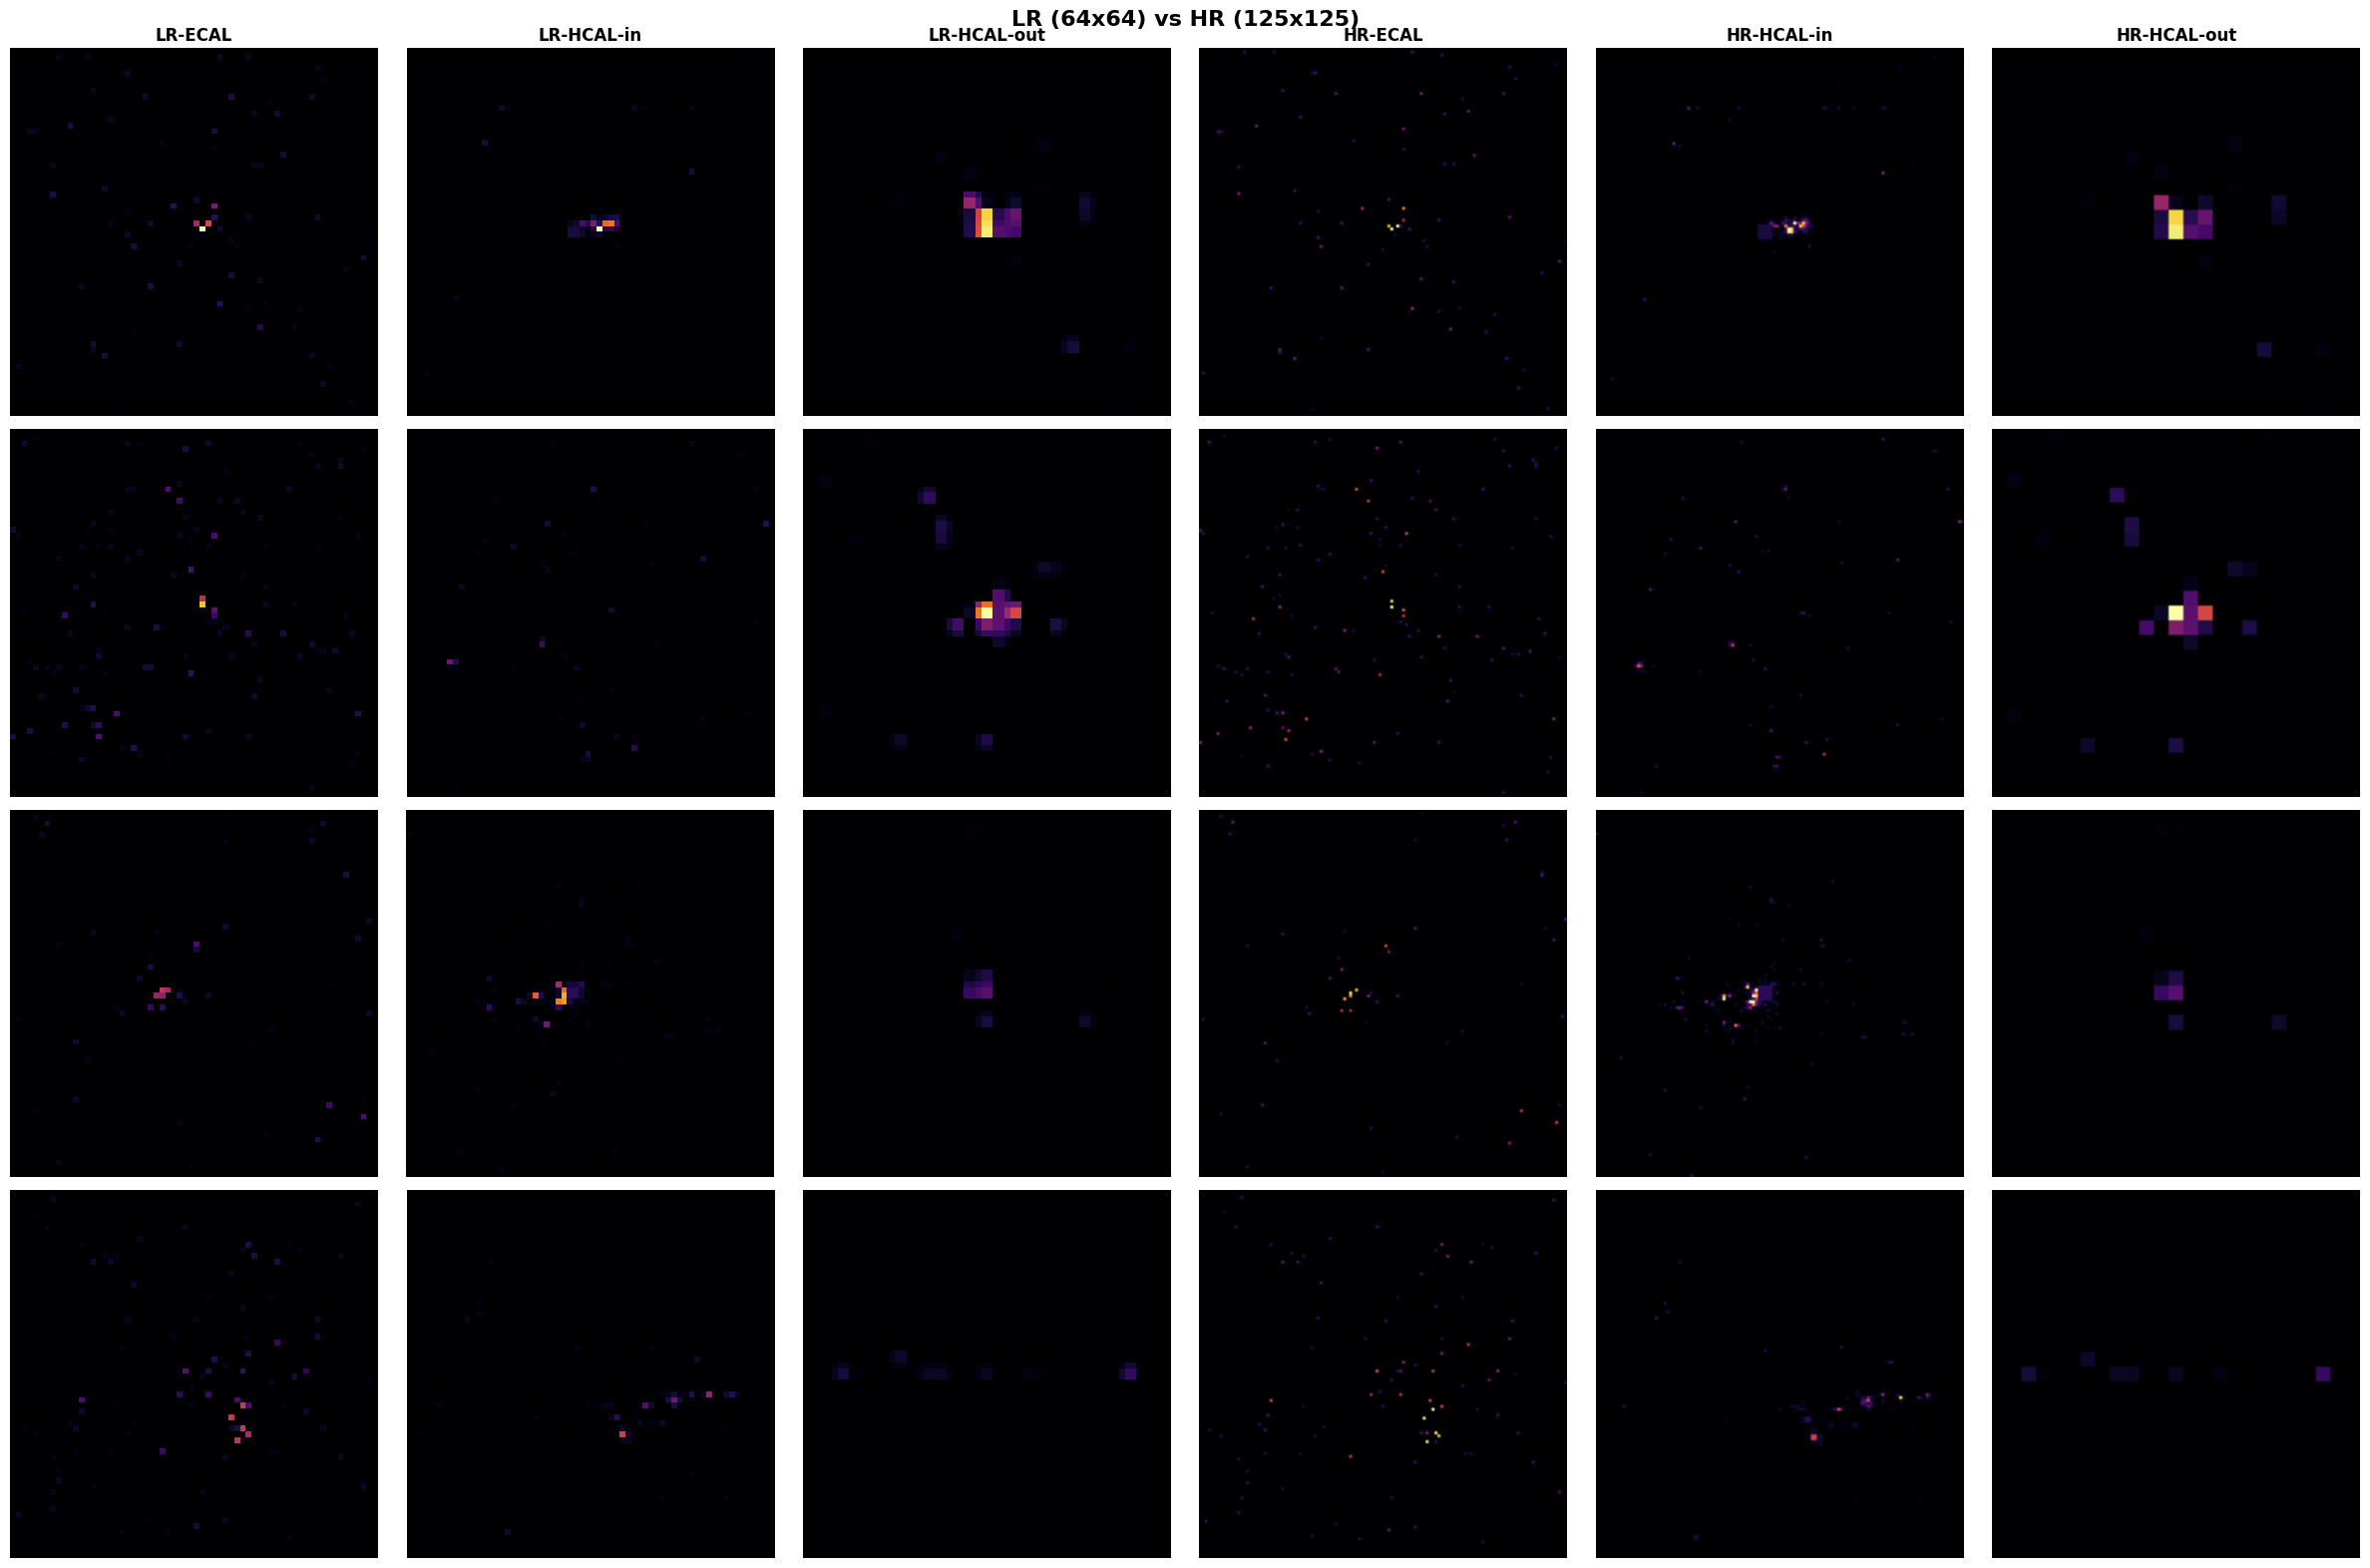

In [19]:
plot_dataset_samples(test_loader)

## 3. ESRGAN Architecture

RRDB Generator (no BN) + VGG Discriminator (spectral norm). Non-integer upsample: bilinear 2× → learned resize to 125.

Architecture is defined in `src/models.py`.

In [20]:
generator = ESRGANGenerator(NUM_CHANNELS, NUM_CHANNELS, NUM_FEATURES, NUM_RRDB, GROWTH_CHANNELS, HR_SIZE).to(DEVICE)
discriminator = VGGStyleDiscriminator(NUM_CHANNELS, 64).to(DEVICE)

gp = sum(p.numel() for p in generator.parameters())
dp = sum(p.numel() for p in discriminator.parameters())
print(f"G:{gp:,} | D:{dp:,} | Total:{gp+dp:,}")

with torch.no_grad():
    d = torch.randn(1, NUM_CHANNELS, LR_SIZE, LR_SIZE).to(DEVICE)
    o = generator(d)
    print(f"Forward: {tuple(d.shape)}->{tuple(o.shape)} | D:{tuple(discriminator(o).shape)}")
    del d, o

G:5,906,627 | D:4,816,961 | Total:10,723,588
Forward: (1, 3, 64, 64)->(1, 3, 125, 125) | D:(1, 1)


## 4. Loss Functions

Loss functions (`VGGPerceptualLoss`, `rel_adv_loss`) are defined in `src/losses.py`.

## 5. Training

Training loops (`train_pretrain`, `train_gan`) are defined in `src/train.py`.

**Note:** If pre-trained weights already exist in `outputs/`, they are loaded and training is skipped.

### Bicubic Baseline

In [21]:
bic_m = bicubic_baseline(test_loader)
print(f"Bicubic baseline: PSNR={bic_m['psnr']:.2f} SSIM={bic_m['ssim']:.4f} MAE={bic_m['mae']:.6f}")

Bicubic baseline: PSNR=44.35 SSIM=0.9828 MAE=0.000665


### Phase 1: L1 Pre-training

In [22]:
pretrained_path = OUTPUT_DIR / "gen_pretrained.pth"

if pretrained_path.exists():
    print(f"Found existing pretrained weights at {pretrained_path}, skipping Phase 1 training.")
    generator.load_state_dict(torch.load(pretrained_path, map_location=DEVICE, weights_only=True))
    pretrain_hist = None
else:
    pretrain_hist = train_pretrain(generator, train_loader, val_loader, DEVICE, PRETRAIN_EPOCHS)

Found existing pretrained weights at /home/nirbhay/Desktop/ML/Gsoc/Super_Resolution/outputs/gen_pretrained.pth, skipping Phase 1 training.


### Phase 2: GAN Fine-tuning

In [23]:
esrgan_path = OUTPUT_DIR / "esrgan_best.pth"

if esrgan_path.exists():
    print(f"Found existing ESRGAN weights at {esrgan_path}, skipping Phase 2 training.")
    ckpt = torch.load(esrgan_path, map_location=DEVICE, weights_only=True)
    generator.load_state_dict(ckpt["gen"])
    discriminator.load_state_dict(ckpt["disc"])
    gan_hist = None
else:
    # Load pretrained weights before GAN fine-tuning
    if pretrained_path.exists():
        generator.load_state_dict(torch.load(pretrained_path, map_location=DEVICE, weights_only=True))
        print("Loaded pretrained weights for GAN fine-tuning.")
    gan_hist = train_gan(generator, discriminator, train_loader, val_loader, DEVICE, GAN_EPOCHS)

Found existing ESRGAN weights at /home/nirbhay/Desktop/ML/Gsoc/Super_Resolution/outputs/esrgan_best.pth, skipping Phase 2 training.


## 6. Final Evaluation

In [24]:
# Load best ESRGAN model for evaluation
ckpt = torch.load(OUTPUT_DIR / "esrgan_best.pth", map_location=DEVICE, weights_only=True)### 7.3 Per-Channel Comparison)
generator.load_state_dict(ckpt["gen"])

tm = evaluate(generator, test_loader, DEVICE)

print(f"{'='*55}")
print(f"  FINAL TEST RESULTS")
print(f"{'='*55}")
print(f"  Bicubic:  PSNR={bic_m['psnr']:.2f}  SSIM={bic_m['ssim']:.4f}  MAE={bic_m['mae']:.6f}")
print(f"  ESRGAN:   PSNR={tm['psnr']:.2f}  SSIM={tm['ssim']:.4f}  MAE={tm['mae']:.6f}")
print(f"  Gain:     dPSNR={tm['psnr']-bic_m['psnr']:+.2f}  dSSIM={tm['ssim']-bic_m['ssim']:+.4f}")
print(f"{'='*55}")

  FINAL TEST RESULTS
  Bicubic:  PSNR=44.35  SSIM=0.9828  MAE=0.000665
  ESRGAN:   PSNR=45.28  SSIM=0.9847  MAE=0.000414
  Gain:     dPSNR=+0.93  dSSIM=+0.0019


## 7. Visualizations
### 7.1 Training Curves

In [25]:
if pretrain_hist is not None and gan_hist is not None:
    plot_training_curves(pretrain_hist, gan_hist)
else:
    print("Training history not available (weights were loaded from cache). Skipping training curves.")

Training history not available (weights were loaded from cache). Skipping training curves.


### 7.2 SR Examples

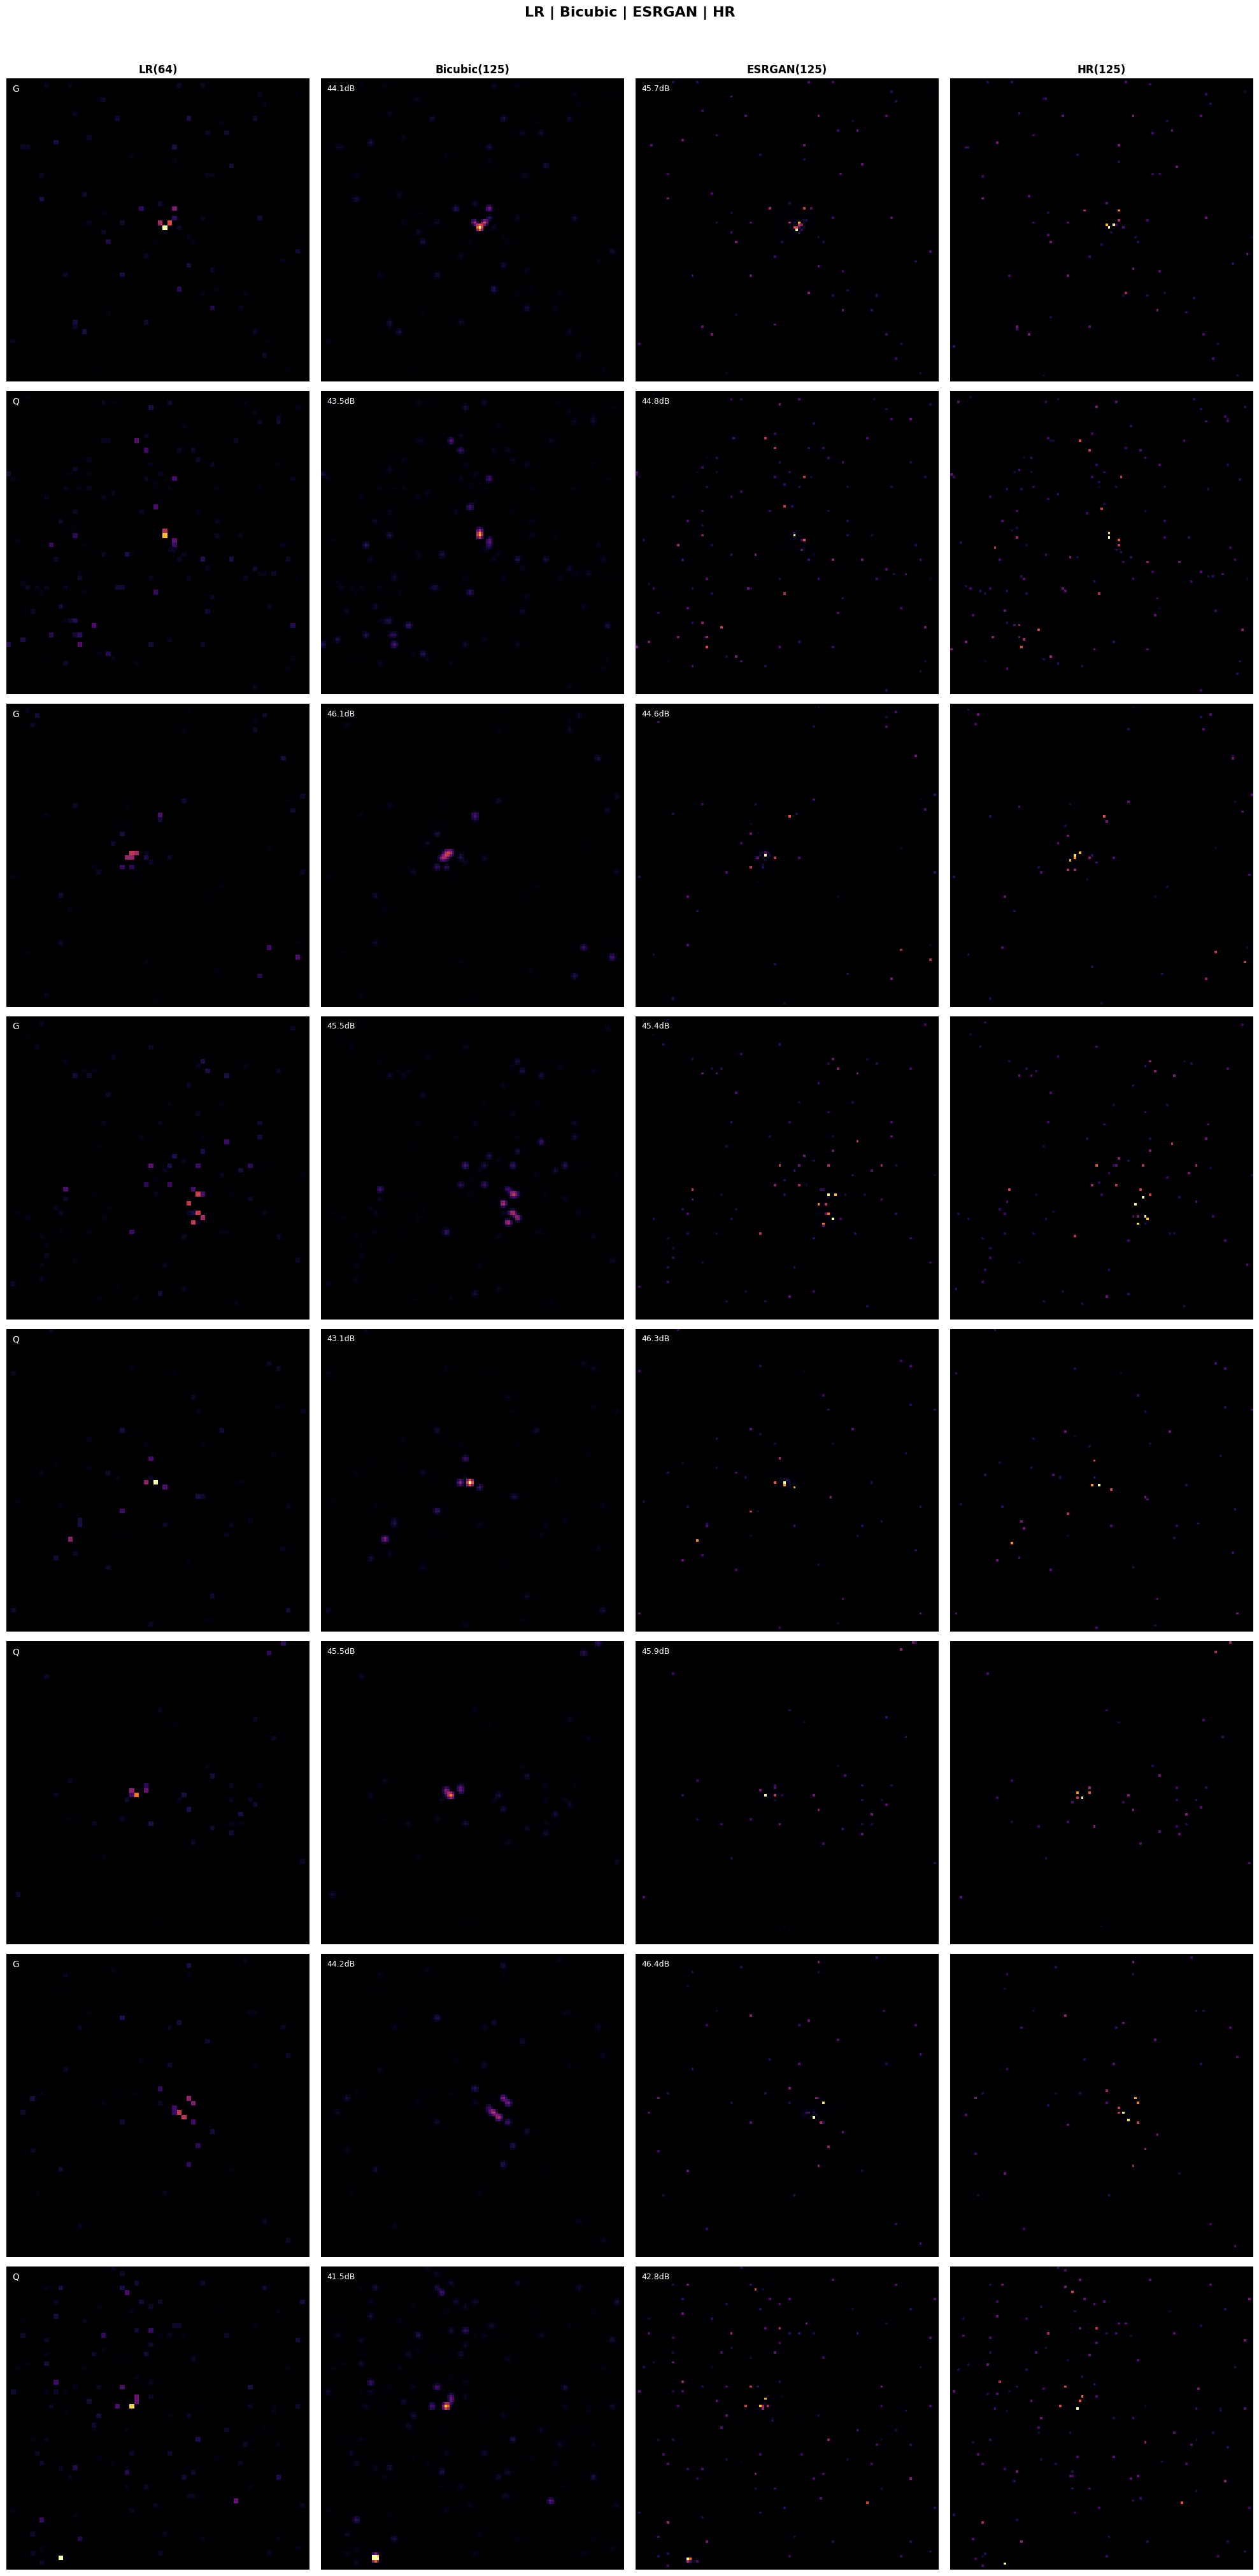

In [26]:
plot_sr_comparison(generator, test_loader, DEVICE)

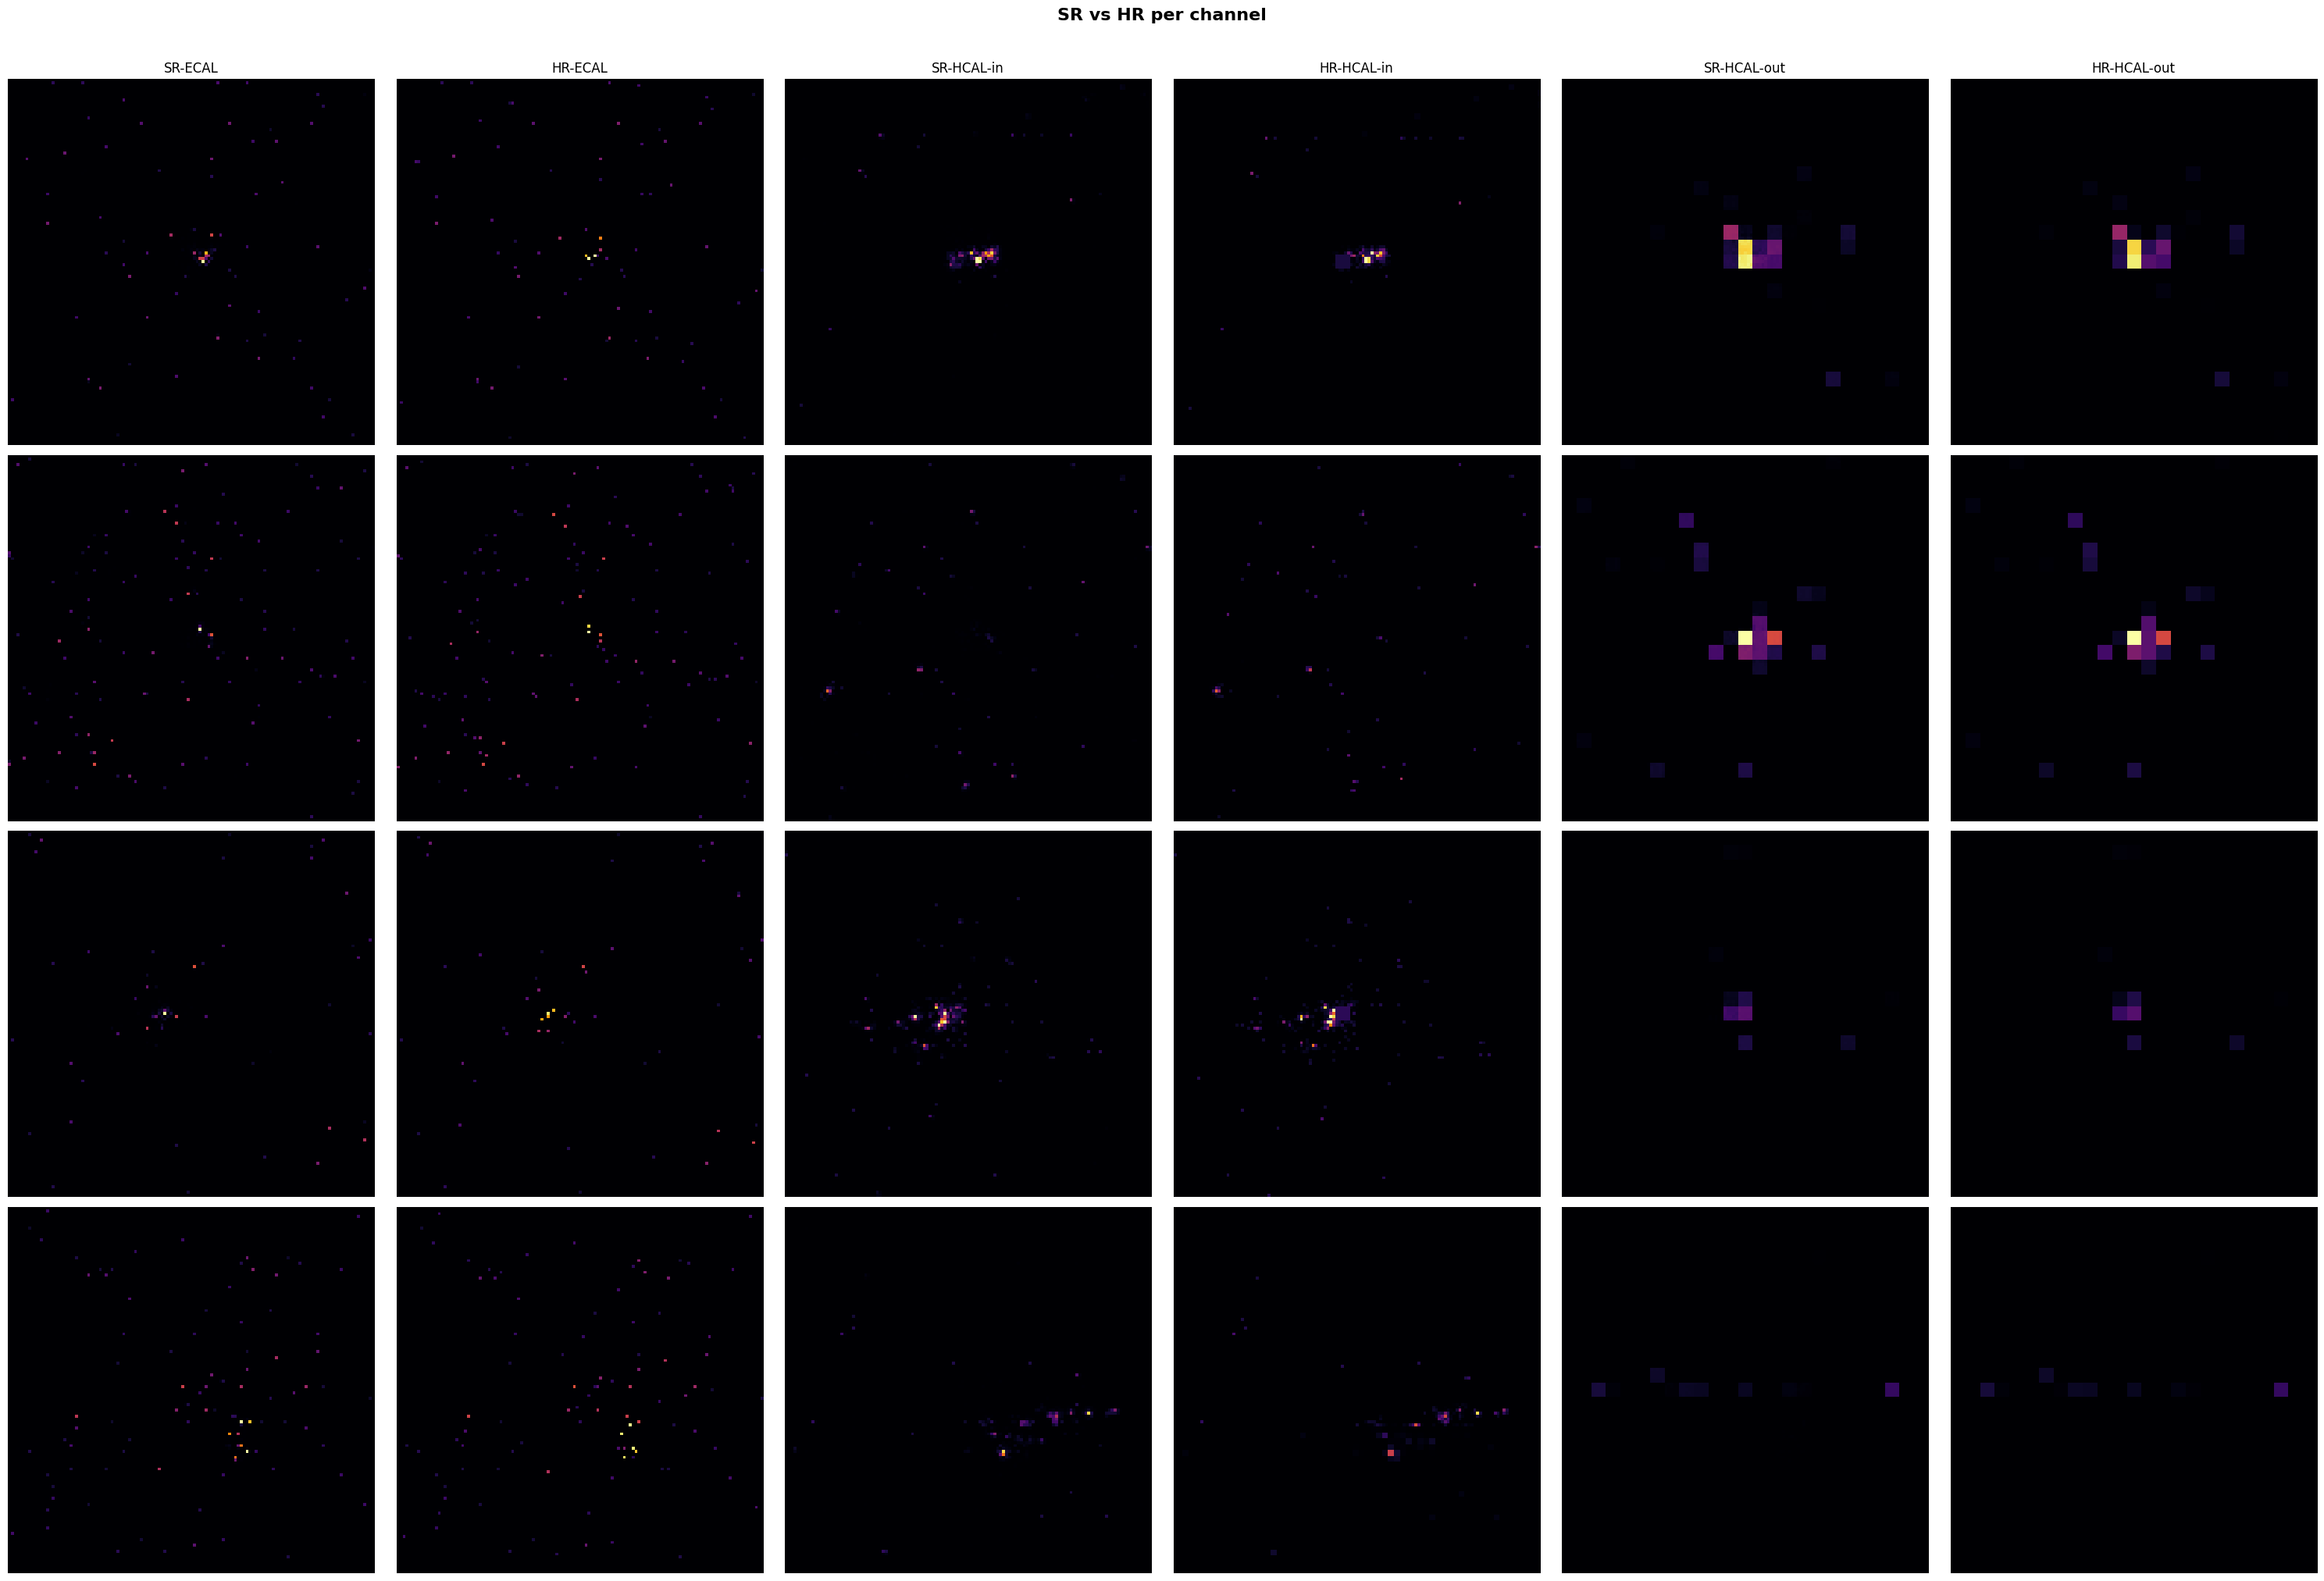

In [27]:
### 7.3 Per-Channel Comparison
plot_channel_comparison(generator, test_loader, DEVICE)

### 7.4 Metric Distributions

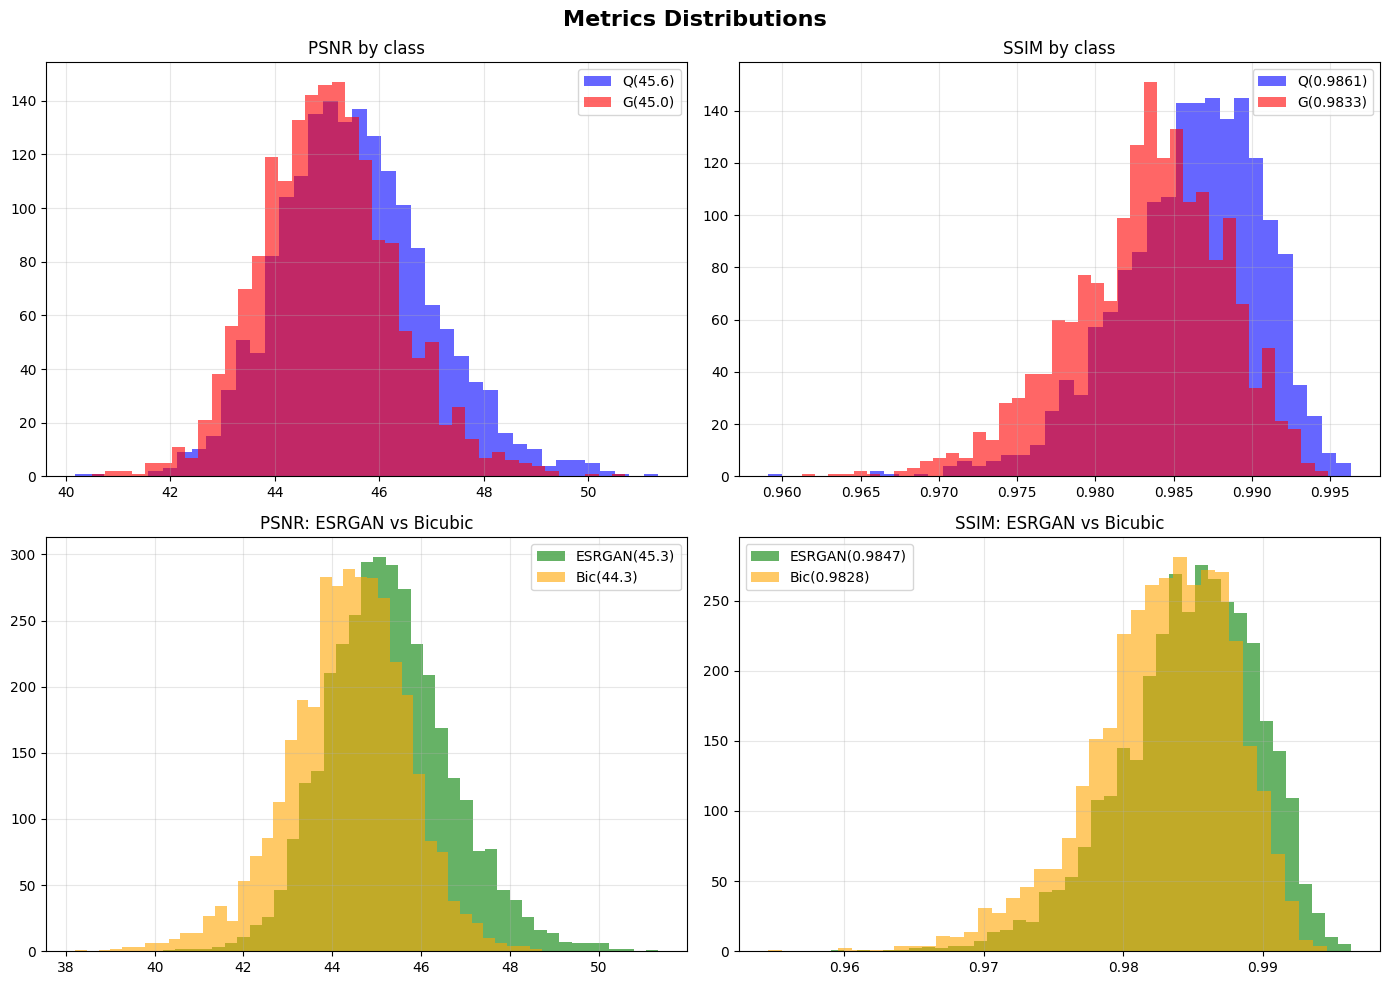

In [28]:
plot_metric_distributions(generator, test_loader, DEVICE)

### 7.5 Difference Maps (Absolute Error)

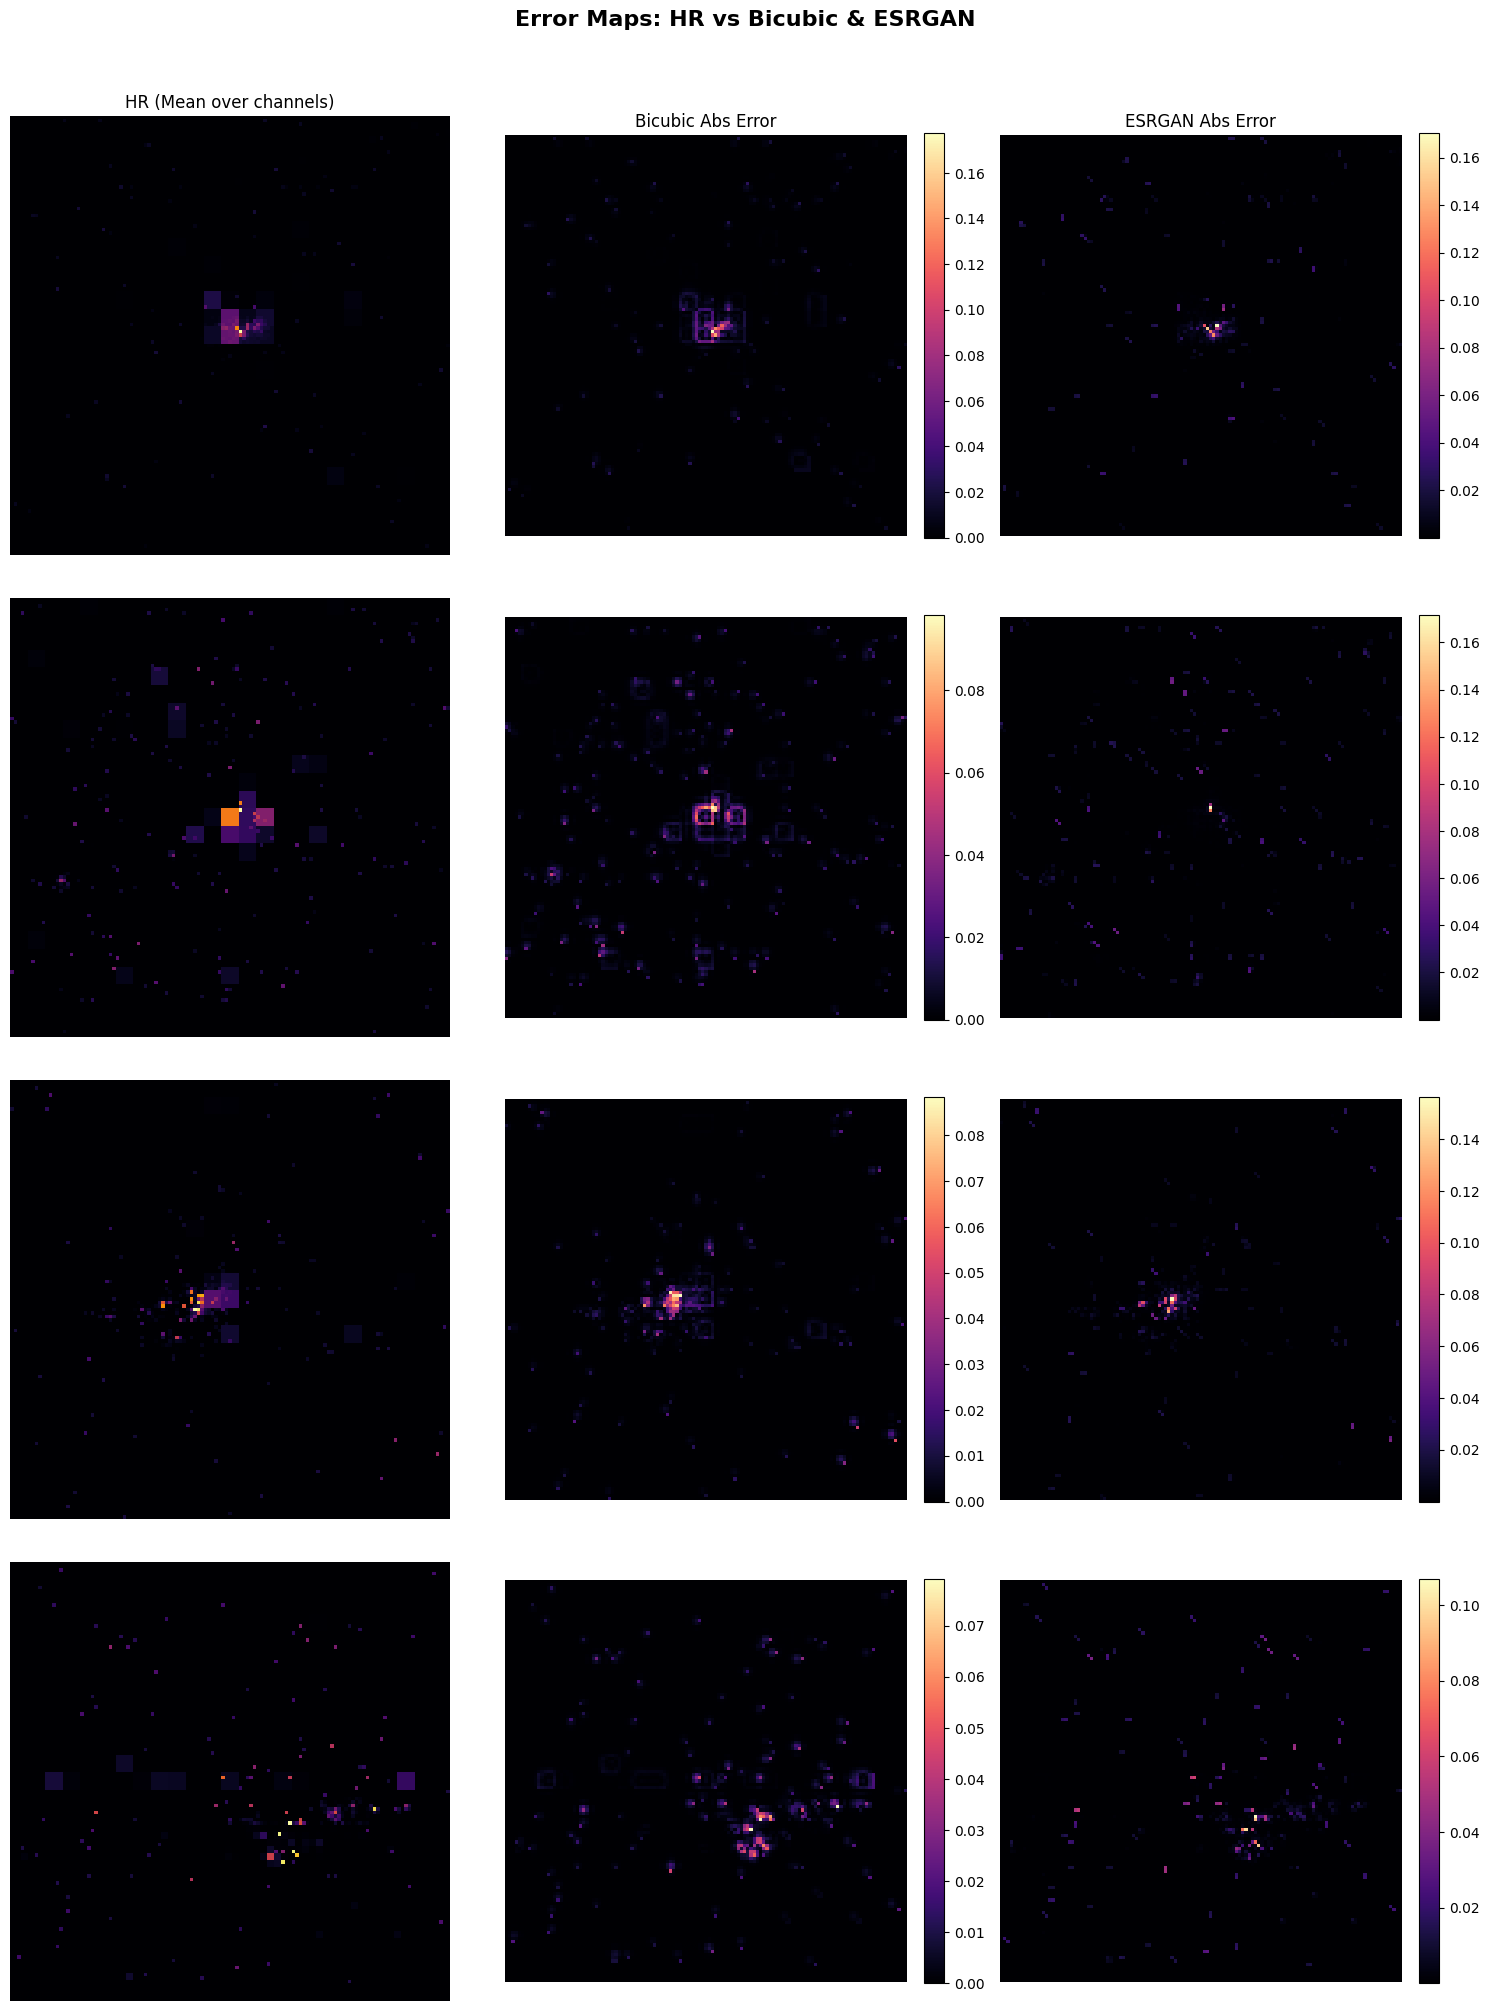

In [29]:
plot_difference_maps(generator, test_loader, DEVICE, num_samples=4)

## 8. Final Summary & Discussion

### Model Selection & Optimization Choices
For this task, an **ESRGAN (Enhanced Super-Resolution GAN)** architecture was selected over standard SRGANs or basic CNNs. The primary reason is the removal of Batch Normalization layers and the introduction of Residual-in-Residual Dense Blocks (RRDB). In sparse physics datasets like calorimeter images, Batch Norm can introduce artifacts by normalizing over mostly empty spaces. 

The training was intentionally split into two phases:
1.  **L1 Pre-training:** To orient the generator toward the basic structural layout of the jets without the unstable dynamics of an adversarial loss.
2.  **GAN Fine-Tuning:** Incorporating a Relativistic Average Discriminator and VGG Perceptual Loss to force the generator to reconstruct the high-frequency "sharpness" of the central energy deposits.

### Hardware Limitations & Workarounds
Given limited computational resources, loading the entire dataset into RAM was not feasible. To mitigate this, a robust data pipeline was engineered using `numpy.memmap`. This allowed the dataset to be streamed directly from disk with minimal overhead. Furthermore, Automatic Mixed Precision (AMP) was heavily utilized during training to maximize batch size and throughput while staying within GPU VRAM constraints.

### Future Improvements
If granted more time and compute, the following would be worth exploring:
1.  **Physics-Informed Loss Functions:** Currently, the network optimizes for pixel-perfect reconstruction and perceptual similarity. Introducing a custom loss term that penalizes the violation of energy conservation (ensuring the total energy integral of the LR image matches the HR image) could yield more physically accurate upsampling.
2.  **Denoising Diffusion Probabilistic Models (DDPMs):** Exploring a conditional Diffusion model (like SR3) instead of a GAN. While slower to sample, diffusion models often avoid the mode-collapse and hallucination issues sometimes present in GANs, offering better uncertainty quantification for scientific data.
3.  **Channel-Specific Attention:** Tracks, ECAL, and HCAL have vastly different sparsity profiles. Applying a Channel Attention mechanism (like SENet) could help the network weight the importance of specific sub-detectors dynamically.

In [ ]:
print("End")

Done!
